<a href="https://colab.research.google.com/github/sehoonyoon/Test/blob/main/%EC%9D%8C%EC%A3%BC%EC%9A%B4%EC%A0%84_%EA%B0%80%EC%84%A4%EA%B2%80%EC%A6%9D%EA%B3%BC%EC%A0%9C.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
# 🚗 음주운전 교통사고 데이터 가설 검증
#**데이터**: 가해자 음주정도별 주야별 교통사고 (2024년)

#| 가설 | 내용 |
#|------|------|
#| 1 | 야간 음주운전 사고건수 > 주간 |
#| 2 | 혈중알코올농도 높을수록 사망자수 증가 |
#| 3 | 야간 고농도 음주운전 비율 > 주간 |
#| 4 | 음주운전 부상자 비율 > 정상운전 |
#| 5 | 연말(11~12월) 음주운전 사고 증가 |
#| 6 | 야간 고농도 사망률 > 야간 저농도 |
#| 7 | 음주운전 사고는 새벽(야간) 집중 |


In [4]:
# ── 0. 한글 폰트 설치 (최초 1회만 실행 후 런타임 재시작 필요) ──
import subprocess
subprocess.run(['apt-get', 'install', '-y', '-q', 'fonts-nanum'], capture_output=True)

import matplotlib.font_manager as fm
fm._load_fontmanager(try_read_cache=False)  # 폰트 캐시 강제 갱신

# 설치 확인
nanum_fonts = [f.name for f in fm.fontManager.ttflist if 'Nanum' in f.name]
print('설치된 나눔 폰트:', set(nanum_fonts))
print('✅ 폰트 설치 완료! 이제 아래 셀을 실행하세요.')

설치된 나눔 폰트: set()
✅ 폰트 설치 완료! 이제 아래 셀을 실행하세요.


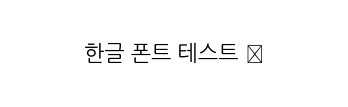

✅ 한글 폰트 적용 완료: NanumGothic


In [1]:
# ── 1. 패키지 import 및 한글 폰트 적용 ──────────────────────────
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# NanumGothic 폰트 경로 직접 지정 (캐시 문제 우회)
font_path = '/usr/share/fonts/truetype/nanum/NanumGothic.ttf'
font_prop = fm.FontProperties(fname=font_path)
font_name = font_prop.get_name()

plt.rcParams['font.family'] = font_name
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

# 폰트 적용 확인용 테스트
fig, ax = plt.subplots(figsize=(3, 1))
ax.text(0.5, 0.5, '한글 폰트 테스트 ✅', ha='center', va='center', fontsize=13)
ax.axis('off')
plt.tight_layout()
plt.show()
print('✅ 한글 폰트 적용 완료:', font_name)

In [2]:
# ── 1. 데이터 로드 ────────────────────────────────────────────
from google.colab import files
uploaded = files.upload()  # CSV 파일 선택
FILE_PATH = list(uploaded.keys())[0]

df_raw = pd.read_csv(FILE_PATH, encoding='euc-kr', header=1)
df_raw.columns = ['구분1', '음주정도', '주야', '월', '사고건수', '사망자수', '부상자수']

df = df_raw[df_raw['월'] != '전체'].copy()
df_drink  = df[df['구분1'] == '음주운전'].copy()
df_normal = df[df['구분1'] == '정상운전'].copy()
df_drink['월_num']  = df_drink['월'].str.replace('월','').astype(int)
df_normal['월_num'] = df_normal['월'].str.replace('월','').astype(int)

BAC_ORDER = ['0.03~0.049%','0.05%~0.079%','0.08%~0.149%',
             '0.15%~0.199%','0.2%~0.249%','0.25%~0.299%',
             '0.3%~0.349%','0.35%이상','측정불능']
LOW_BAC  = ['0.03~0.049%','0.05%~0.079%','0.08%~0.149%']
HIGH_BAC = ['0.15%~0.199%','0.2%~0.249%','0.25%~0.299%','0.3%~0.349%','0.35%이상']

C_DAY='#4A90D9'; C_NIGHT='#E8604C'; C_HIGH='#D94A4A'; C_LOW='#4AD9A4'; C_GRAY='#AAAAAA'

print('✅ 데이터 로드 완료 | 총 행 수:', len(df_drink))
print(df_drink.head(3))

Saving 가해자_음주정도별_주야별_교통사고_20260529232548.csv to 가해자_음주정도별_주야별_교통사고_20260529232548.csv
✅ 데이터 로드 완료 | 총 행 수: 216
    구분1         음주정도 주야   월  사고건수  사망자수  부상자수  월_num
1  음주운전  0.03~0.049%  주  1월    18     0    31      1
2  음주운전  0.03~0.049%  주  2월    22     0    45      2
3  음주운전  0.03~0.049%  주  3월    20     0    28      3


주간 합계: 3,148건 | 야간 합계: 7,889건
결론: 가설 ✅ 지지 (야간이 4,741건 더 많음)


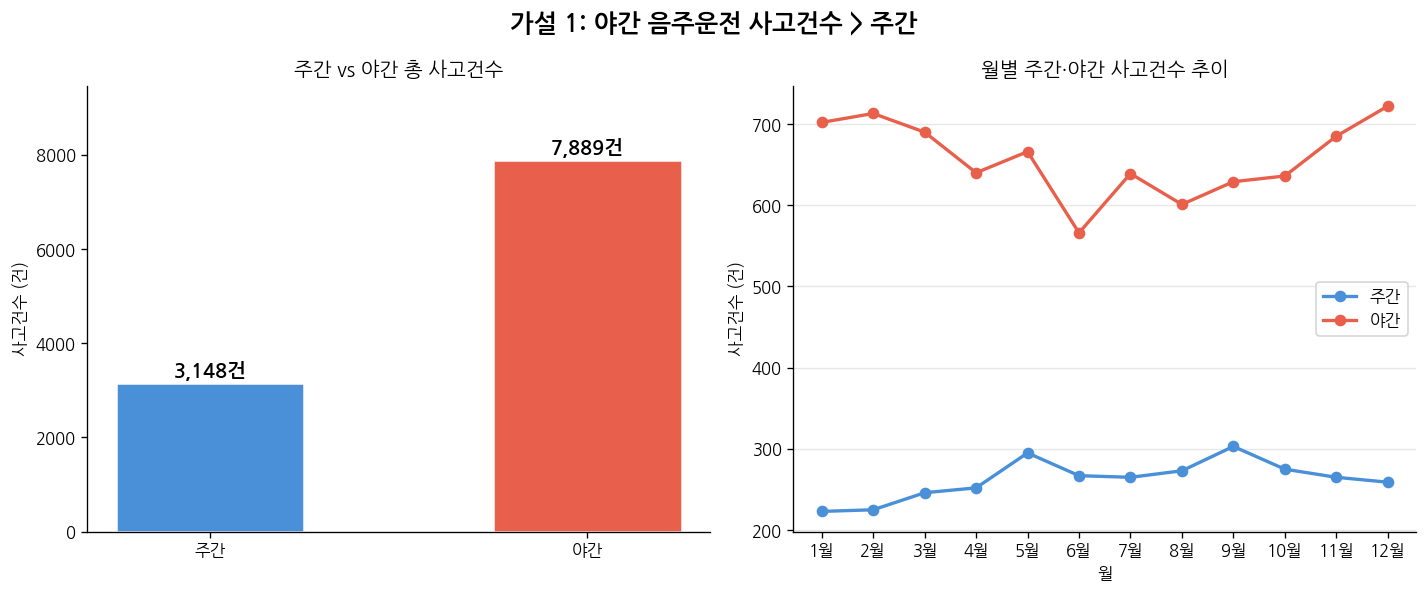

In [4]:
'''
 가설 1: 야간 음주운전 사고 건수> 주간
 -> 음주운전은 회식, 유흥 활동 이후 발생하는 경우가 많아 야간 시간대에 집중될 가능성이 높다
'''

h1 = df_drink.groupby('주야')['사고건수'].sum().reset_index()
day_cnt   = h1.loc[h1['주야']=='주','사고건수'].values[0]
night_cnt = h1.loc[h1['주야']=='야','사고건수'].values[0]
print(f'주간 합계: {day_cnt:,}건 | 야간 합계: {night_cnt:,}건')
print(f'결론: 가설 {"✅ 지지" if night_cnt>day_cnt else "❌ 기각"} (야간이 {abs(night_cnt-day_cnt):,}건 더 {"많음" if night_cnt>day_cnt else "적음"})')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('가설 1: 야간 음주운전 사고건수 > 주간', fontsize=15, fontweight='bold')

bars = axes[0].bar(['주간','야간'], [day_cnt, night_cnt],
                   color=[C_DAY, C_NIGHT], width=0.5, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, [day_cnt, night_cnt]):
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+50,
                 f'{val:,}건', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('주간 vs 야간 총 사고건수', fontsize=12)
axes[0].set_ylabel('사고건수 (건)')
axes[0].set_ylim(0, max(day_cnt, night_cnt)*1.2)

h1_month = df_drink.groupby(['주야','월_num'])['사고건수'].sum().reset_index()
for label, color in [('주', C_DAY), ('야', C_NIGHT)]:
    sub = h1_month[h1_month['주야']==label].sort_values('월_num')
    axes[1].plot(sub['월_num'], sub['사고건수'], marker='o', color=color,
                 linewidth=2, markersize=6, label=f"{'주간' if label=='주' else '야간'}")
axes[1].set_title('월별 주간·야간 사고건수 추이', fontsize=12)
axes[1].set_xlabel('월'); axes[1].set_ylabel('사고건수 (건)')
axes[1].set_xticks(range(1,13))
axes[1].set_xticklabels([f'{m}월' for m in range(1,13)])
axes[1].legend(); axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

        음주정도  사고건수  사망자수  사망률(%)
 0.03~0.049%   680     5    0.74
0.05%~0.079%  1677    32    1.91
0.08%~0.149%  4777    48    1.00
0.15%~0.199%  2538    34    1.34
0.25%~0.299%   158     3    1.90
     0.35%이상    15     1    6.67


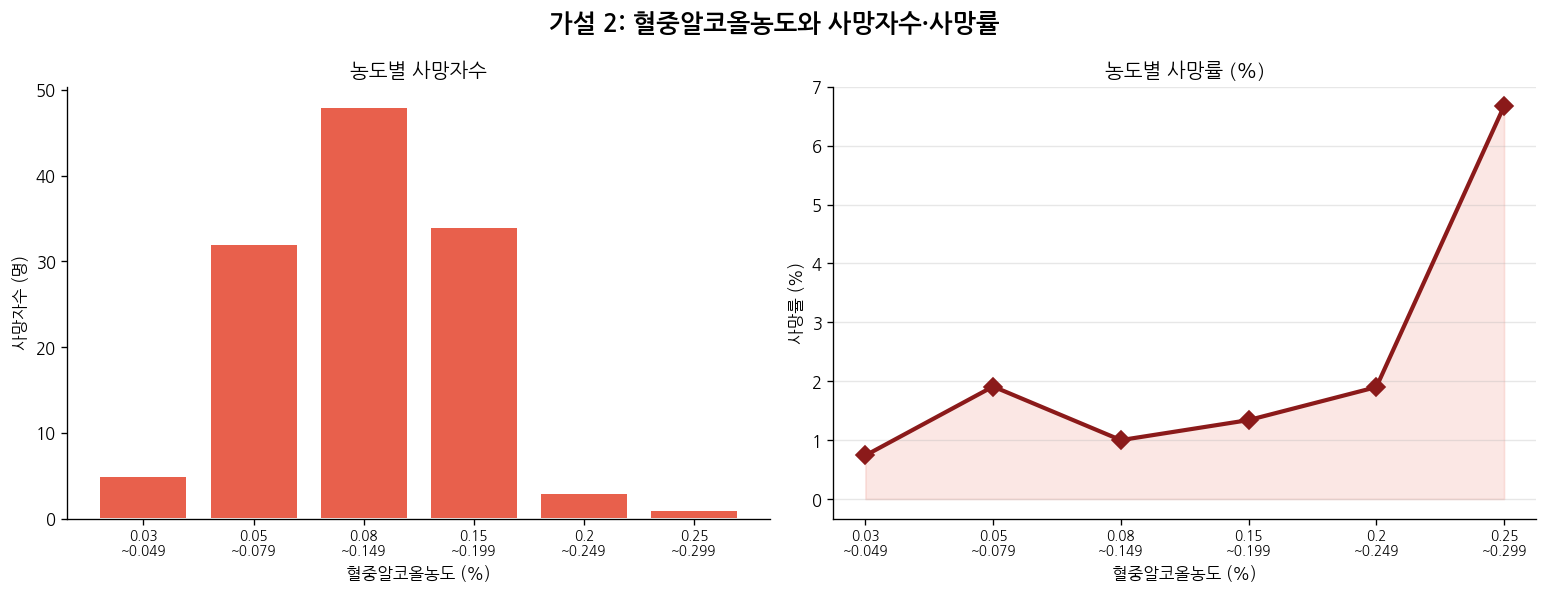

In [6]:
'''
 가설 2: 혈중알코올농도 높을수록 사망자수 증가
-> 음주 정도가 심할수록 판단력과 반응속도가 크게 저하되어 치명적인 사고로 이어질 가능성이 높다.
'''

h2 = (df_drink[df_drink['음주정도'].isin(BAC_ORDER[:-1])]
      .groupby('음주정도')[['사고건수','사망자수']].sum().reset_index())
h2['사망률(%)'] = (h2['사망자수']/h2['사고건수']*100).round(2)
h2['순서'] = h2['음주정도'].map({v:i for i,v in enumerate(BAC_ORDER)})
h2 = h2.sort_values('순서').reset_index(drop=True)
print(h2[['음주정도','사고건수','사망자수','사망률(%)']].to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('가설 2: 혈중알코올농도와 사망자수·사망률', fontsize=15, fontweight='bold')

short = ['0.03\n~0.049','0.05\n~0.079','0.08\n~0.149',
         '0.15\n~0.199','0.2\n~0.249','0.25\n~0.299',
         '0.3\n~0.349','0.35\n이상']
# 실제 데이터 행 수에 맞게 자르기
short = short[:len(h2)]
x = list(range(len(h2)))

axes[0].bar(x, h2['사망자수'], color='#E8604C', edgecolor='white', linewidth=1.2)
axes[0].set_title('농도별 사망자수', fontsize=12)
axes[0].set_xlabel('혈중알코올농도 (%)'); axes[0].set_ylabel('사망자수 (명)')
axes[0].set_xticks(x)
axes[0].set_xticklabels(short, fontsize=8)

axes[1].plot(x, h2['사망률(%)'], marker='D', color='#8B1A1A', linewidth=2.5, markersize=8)
axes[1].fill_between(x, h2['사망률(%)'], alpha=0.15, color='#E8604C')
axes[1].set_title('농도별 사망률 (%)', fontsize=12)
axes[1].set_xlabel('혈중알코올농도 (%)'); axes[1].set_ylabel('사망률 (%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(short, fontsize=8)
axes[1].grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()


농도구분  고농도(0.15%↑)  저농도(0.15%↓)  고농도비율(%)
주야                                      
야            2031         5004     28.87
주             680         2130     24.20
결론: 가설 ❌ 기각 (주간 28.9% vs 야간 24.2%)


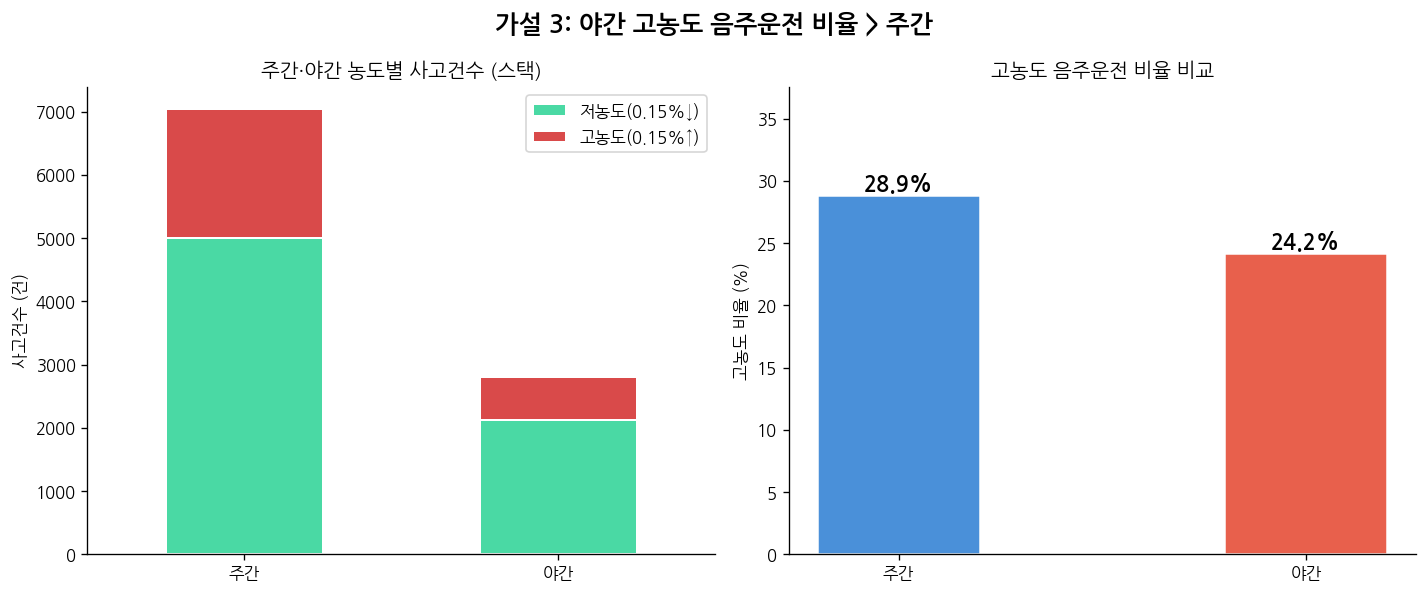

In [7]:
'''
가설 3: 야간 고농도 음주운전 비율 > 주간
-> 야간에는 장시간 음주 후 운전하는 경우가 많아 상대적으로 높은 음주 수치가 나타날 수 있다
'''

df_bac = df_drink[df_drink['음주정도'].isin(LOW_BAC+HIGH_BAC)].copy()
df_bac['농도구분'] = df_bac['음주정도'].apply(lambda x: '고농도(0.15%↑)' if x in HIGH_BAC else '저농도(0.15%↓)')
h3 = df_bac.groupby(['주야','농도구분'])['사고건수'].sum().unstack(fill_value=0)
h3['고농도비율(%)'] = (h3['고농도(0.15%↑)']/(h3['고농도(0.15%↑)']+h3['저농도(0.15%↓)'])*100).round(2)
ratio_vals = h3['고농도비율(%)'].values
print(h3)
print(f'결론: 가설 {"✅ 지지" if ratio_vals[1]>ratio_vals[0] else "❌ 기각"} (주간 {ratio_vals[0]:.1f}% vs 야간 {ratio_vals[1]:.1f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('가설 3: 야간 고농도 음주운전 비율 > 주간', fontsize=15, fontweight='bold')
h3_plot = h3[['저농도(0.15%↓)','고농도(0.15%↑)']].copy()
h3_plot.index = ['주간','야간']
h3_plot.plot(kind='bar', stacked=True, ax=axes[0],
             color=[C_LOW, C_HIGH], edgecolor='white', linewidth=1.2, rot=0)
axes[0].set_title('주간·야간 농도별 사고건수 (스택)', fontsize=12)
axes[0].set_ylabel('사고건수 (건)'); axes[0].legend(loc='upper right')

axes[1].bar(['주간','야간'], ratio_vals, color=[C_DAY, C_NIGHT], width=0.4, edgecolor='white', linewidth=1.5)
for i, v in enumerate(ratio_vals):
    axes[1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold')
axes[1].set_title('고농도 음주운전 비율 비교', fontsize=12)
axes[1].set_ylabel('고농도 비율 (%)')
axes[1].set_ylim(0, max(ratio_vals)*1.3)
plt.tight_layout(); plt.show()

음주운전 부상자/사고 비율: 1.550
정상운전 부상자/사고 비율: 1.410
결론: 가설 ✅ 지지


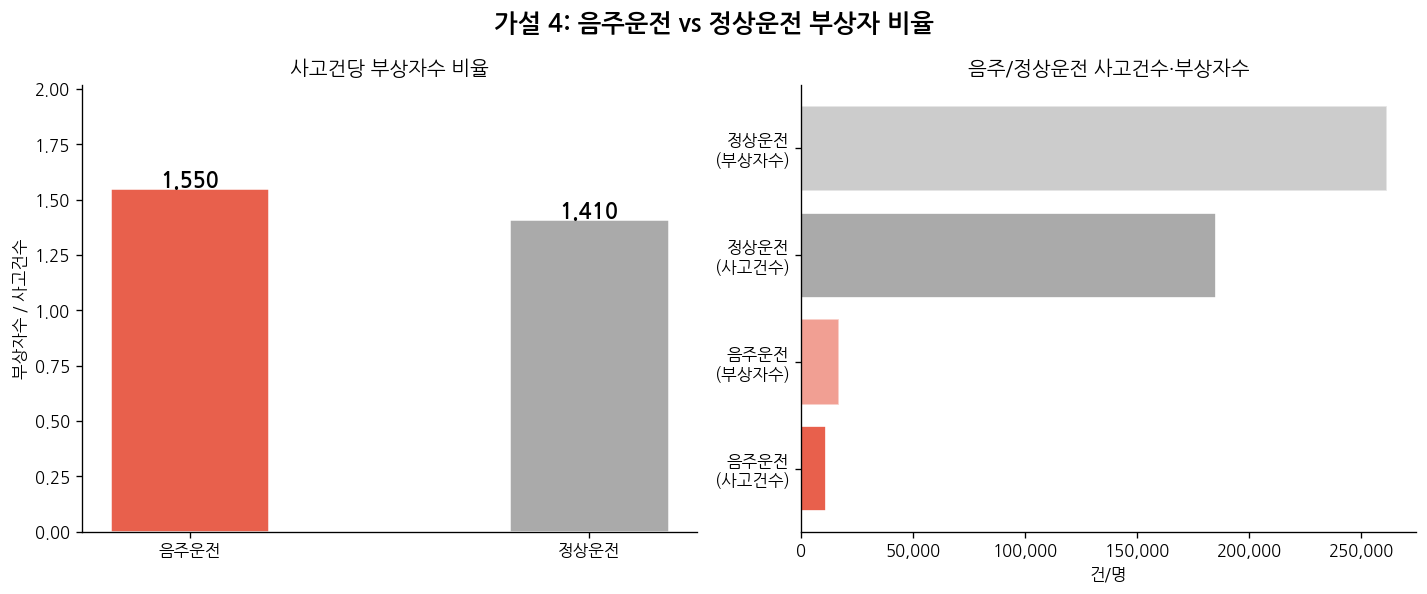

In [9]:
'''
가설 4: 음주운전 사고 부상자 비율> 정상운전
-> 음주 상태에서는 과속이나 신호위반 가능성이 높아 충돌 강도가 커질 수 있다.
'''

drink_inj  = df_drink[['사고건수','부상자수']].sum()
normal_inj = df_normal[['사고건수','부상자수']].sum()
drink_ratio  = drink_inj['부상자수']/drink_inj['사고건수']
normal_ratio = normal_inj['부상자수']/normal_inj['사고건수']
print(f'음주운전 부상자/사고 비율: {drink_ratio:.3f}')
print(f'정상운전 부상자/사고 비율: {normal_ratio:.3f}')
print(f'결론: 가설 {"✅ 지지" if drink_ratio>normal_ratio else "❌ 기각"}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('가설 4: 음주운전 vs 정상운전 부상자 비율', fontsize=15, fontweight='bold')

# 왼쪽: 사고건당 부상자 비율 막대
axes[0].bar(['음주운전','정상운전'], [drink_ratio, normal_ratio],
            color=[C_NIGHT, C_GRAY], width=0.4, edgecolor='white', linewidth=1.5)
for i2, v in enumerate([drink_ratio, normal_ratio]):
    axes[0].text(i2, v+0.005, f'{v:.3f}', ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('사고건당 부상자수 비율', fontsize=12)
axes[0].set_ylabel('부상자수 / 사고건수')
axes[0].set_ylim(0, max(drink_ratio, normal_ratio)*1.3)

# 오른쪽: 절대 수치 수평 막대 (alpha 리스트 제거)
labels = ['음주운전\n(사고건수)','음주운전\n(부상자수)','정상운전\n(사고건수)','정상운전\n(부상자수)']
values = [drink_inj['사고건수'], drink_inj['부상자수'], normal_inj['사고건수'], normal_inj['부상자수']]
colors = [C_NIGHT, C_NIGHT, C_GRAY, C_GRAY]
alphas = [1.0, 0.6, 1.0, 0.6]
for j, (lb, val, col, alp) in enumerate(zip(labels, values, colors, alphas)):
    axes[1].barh(lb, val, color=col, alpha=alp, edgecolor='white')
axes[1].set_title('음주/정상운전 사고건수·부상자수', fontsize=12)
axes[1].set_xlabel('건/명')
axes[1].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
plt.tight_layout(); plt.show()


기타 월 평균: 910.6건 | 연말 평균: 965.5건
결론: 가설 ✅ 지지


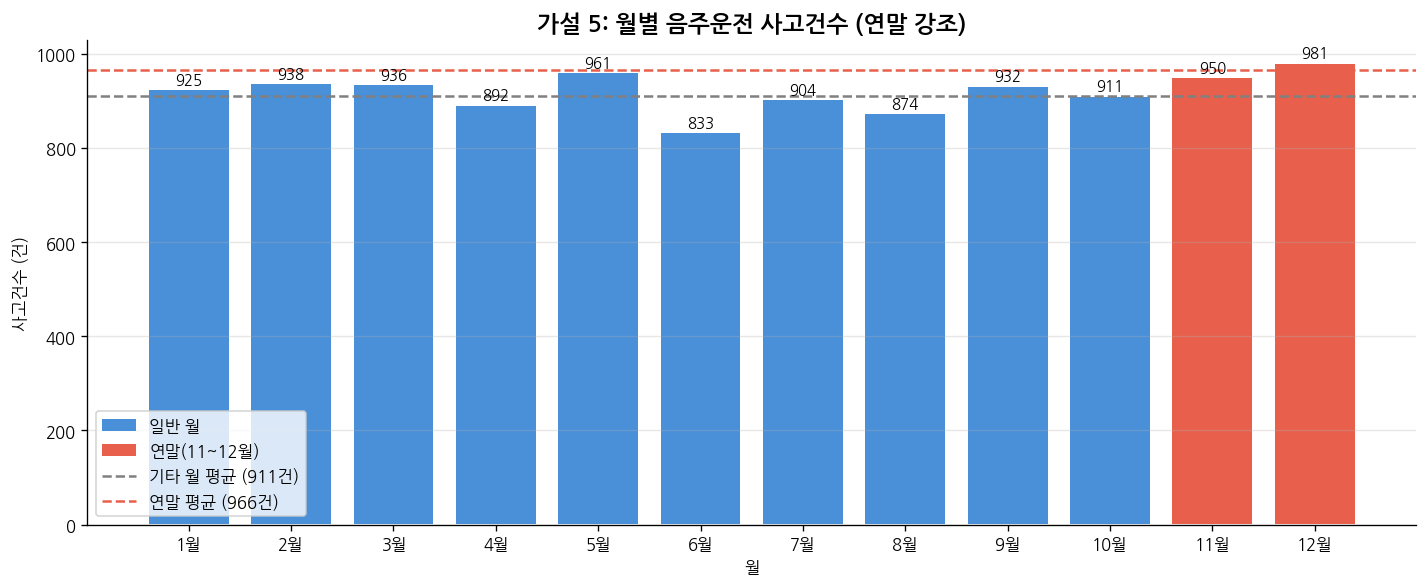

In [10]:
'''
가설 5: 연말(11~12월)음주운전 사고 증가
-> 연말 모임과 회식 증가로 인해 음주운전 발생 가능성이 높아질 수 있다.
'''

from matplotlib.patches import Patch
h5 = df_drink.groupby('월_num')['사고건수'].sum().reset_index()
avg_normal  = h5[h5['월_num']<11]['사고건수'].mean()
avg_yearend = h5[h5['월_num']>=11]['사고건수'].mean()
print(f'기타 월 평균: {avg_normal:.1f}건 | 연말 평균: {avg_yearend:.1f}건')
print(f'결론: 가설 {"✅ 지지" if avg_yearend>avg_normal else "❌ 기각"}')

fig, ax = plt.subplots(figsize=(12, 5))
colors = [C_NIGHT if m>=11 else C_DAY for m in h5['월_num']]
bars = ax.bar(h5['월_num'], h5['사고건수'], color=colors, edgecolor='white', linewidth=1.2)
ax.axhline(avg_normal,  color='gray',   linestyle='--', linewidth=1.5, label=f'기타 월 평균 ({avg_normal:.0f}건)')
ax.axhline(avg_yearend, color=C_NIGHT,  linestyle='--', linewidth=1.5, label=f'연말 평균 ({avg_yearend:.0f}건)')
for bar, val in zip(bars, h5['사고건수']):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+5, str(val),
            ha='center', va='bottom', fontsize=9)
ax.set_title('가설 5: 월별 음주운전 사고건수 (연말 강조)', fontsize=14, fontweight='bold')
ax.set_xlabel('월'); ax.set_ylabel('사고건수 (건)')
ax.set_xticks(range(1,13))
ax.set_xticklabels([f'{m}월' for m in range(1,13)])
legend_els = [Patch(facecolor=C_DAY, label='일반 월'), Patch(facecolor=C_NIGHT, label='연말(11~12월)')]
ax.legend(handles=legend_els + [plt.Line2D([0],[0],color='gray',linestyle='--',label=f'기타 월 평균 ({avg_normal:.0f}건)'),
                                  plt.Line2D([0],[0],color=C_NIGHT,linestyle='--',label=f'연말 평균 ({avg_yearend:.0f}건)')])
ax.grid(axis='y', alpha=0.3)
plt.tight_layout(); plt.show()

             사고건수  사망자수  사망률(%)
농도구분                           
고농도(0.15%↑)  2031    31   1.526
저농도(0.15%↓)  5004    66   1.319
결론: 가설 ✅ 지지 (저농도 1.319% vs 고농도 1.526%)


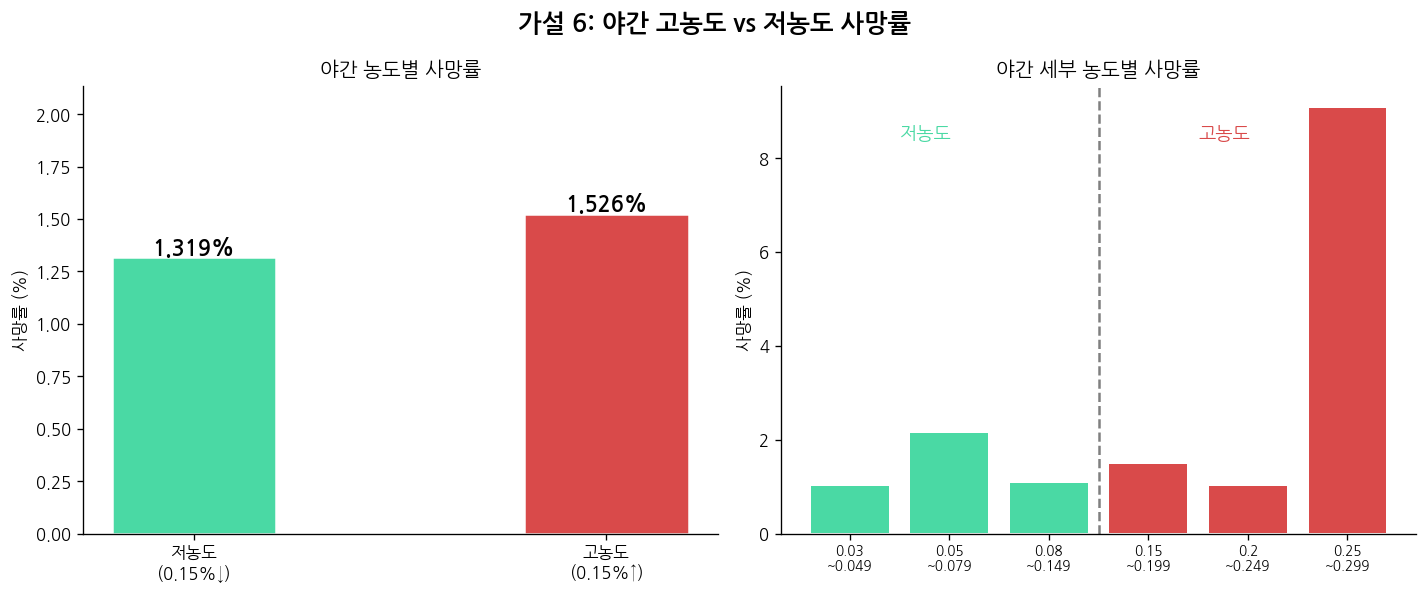

In [11]:
'''
가설 6: 야간 고농도 사망률> 야간 저농도
-> 혈중알코올농도가 높아질수록 운전 통제 능력이 급격히 감소하기 때문이다.
'''

df_night = df_drink[df_drink['주야']=='야'].copy()
df_nb = df_night[df_night['음주정도'].isin(LOW_BAC+HIGH_BAC)].copy()
df_nb['농도구분'] = df_nb['음주정도'].apply(lambda x: '고농도(0.15%↑)' if x in HIGH_BAC else '저농도(0.15%↓)')
h6 = df_nb.groupby('농도구분')[['사고건수','사망자수']].sum()
h6['사망률(%)'] = (h6['사망자수']/h6['사고건수']*100).round(3)
low_rate  = h6.loc['저농도(0.15%↓)','사망률(%)']
high_rate = h6.loc['고농도(0.15%↑)','사망률(%)']
print(h6)
print(f'결론: 가설 {"✅ 지지" if high_rate>low_rate else "❌ 기각"} (저농도 {low_rate:.3f}% vs 고농도 {high_rate:.3f}%)')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('가설 6: 야간 고농도 vs 저농도 사망률', fontsize=15, fontweight='bold')
axes[0].bar(['저농도\n(0.15%↓)','고농도\n(0.15%↑)'], [low_rate, high_rate],
            color=[C_LOW, C_HIGH], width=0.4, edgecolor='white', linewidth=1.5)
for i, v in enumerate([low_rate, high_rate]):
    axes[0].text(i, v+0.01, f'{v:.3f}%', ha='center', fontsize=13, fontweight='bold')
axes[0].set_title('야간 농도별 사망률', fontsize=12)
axes[0].set_ylabel('사망률 (%)')
axes[0].set_ylim(0, max(low_rate, high_rate)*1.4)

h6d = (df_drink[(df_drink['주야']=='야')&(df_drink['음주정도'].isin(BAC_ORDER[:-1]))]
       .groupby('음주정도')[['사고건수','사망자수']].sum())
h6d['사망률'] = h6d['사망자수']/h6d['사고건수']*100
h6d = h6d.reindex([b for b in BAC_ORDER if b in h6d.index])
short = ['0.03\n~0.049','0.05\n~0.079','0.08\n~0.149','0.15\n~0.199',
         '0.2\n~0.249','0.25\n~0.299','0.3\n~0.349','0.35\n이상'][:len(h6d)]
bar_colors = [C_LOW if b in LOW_BAC else C_HIGH for b in h6d.index]
axes[1].bar(range(len(h6d)), h6d['사망률'], color=bar_colors, edgecolor='white', linewidth=1.2)
axes[1].set_xticks(range(len(h6d))); axes[1].set_xticklabels(short, fontsize=8)
axes[1].set_title('야간 세부 농도별 사망률', fontsize=12); axes[1].set_ylabel('사망률 (%)')
axes[1].axvline(2.5, color='black', linestyle='--', alpha=0.5)
axes[1].text(0.5, axes[1].get_ylim()[1]*0.88, '저농도', color=C_LOW, fontsize=11)
axes[1].text(3.5, axes[1].get_ylim()[1]*0.88, '고농도', color=C_HIGH, fontsize=11)
plt.tight_layout(); plt.show()

주간 비율: 28.5% | 야간 비율: 71.5%
결론: 가설 ✅ 지지


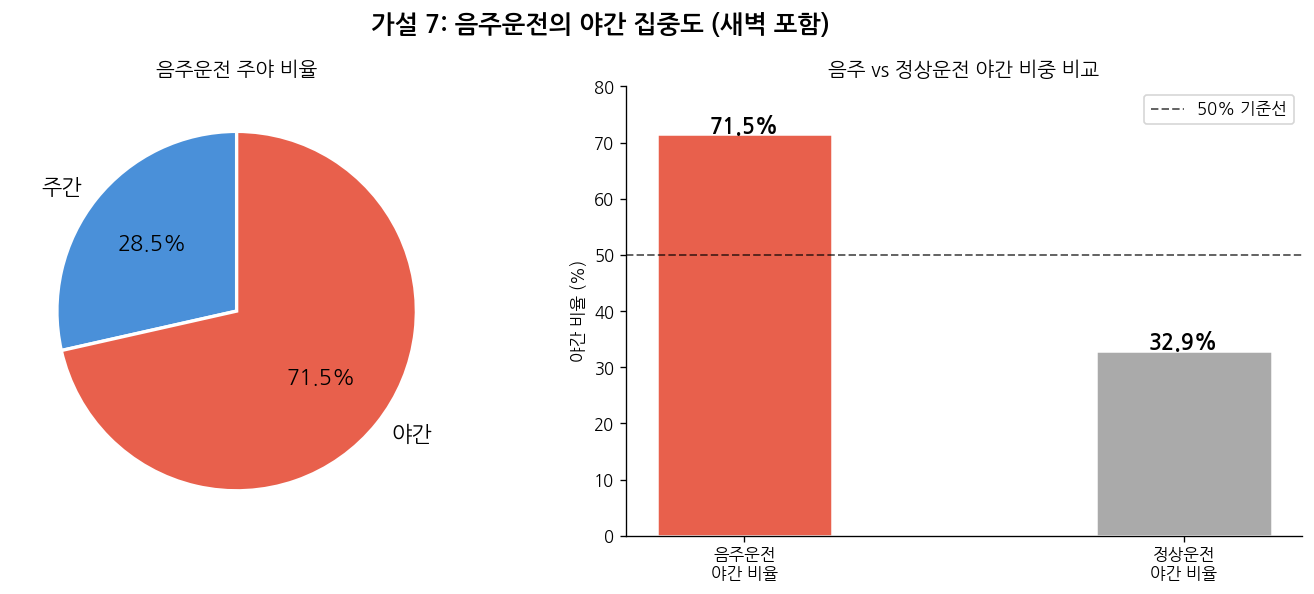

In [12]:
'''
가설 7: 음주운전 사고는 새벽 시간대(야간)에 집중
-> 심야 유흥 활동 이후 귀가 시간과 겹치기 때문이다.
'''

h7 = df_drink.groupby('주야')['사고건수'].sum()
night_pct  = h7['야']/h7.sum()*100
day_pct    = h7['주']/h7.sum()*100
normal_night_pct = (df_normal.groupby('주야')['사고건수'].sum()['야'] /
                    df_normal.groupby('주야')['사고건수'].sum().sum()*100)
print(f'주간 비율: {day_pct:.1f}% | 야간 비율: {night_pct:.1f}%')
print(f'결론: 가설 {"✅ 지지" if night_pct>50 else "❌ 기각 (야간이 과반 미만)"}')

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('가설 7: 음주운전의 야간 집중도 (새벽 포함)', fontsize=15, fontweight='bold')
axes[0].pie([h7['주'], h7['야']], labels=['주간','야간'], colors=[C_DAY, C_NIGHT],
            autopct='%1.1f%%', startangle=90, textprops={'fontsize':13},
            wedgeprops={'edgecolor':'white','linewidth':2})
axes[0].set_title('음주운전 주야 비율', fontsize=12)

axes[1].bar(['음주운전\n야간 비율','정상운전\n야간 비율'],
            [night_pct, normal_night_pct],
            color=[C_NIGHT, C_GRAY], width=0.4, edgecolor='white', linewidth=1.5)
for i, v in enumerate([night_pct, normal_night_pct]):
    axes[1].text(i, v+0.3, f'{v:.1f}%', ha='center', fontsize=13, fontweight='bold')
axes[1].axhline(50, color='black', linestyle='--', linewidth=1.2, alpha=0.6, label='50% 기준선')
axes[1].set_title('음주 vs 정상운전 야간 비중 비교', fontsize=12)
axes[1].set_ylabel('야간 비율 (%)'); axes[1].set_ylim(0, 80); axes[1].legend()
plt.tight_layout(); plt.show()

In [13]:
'''
종합 결과 요약
'''

# 필요한 값 재계산
h1  = df_drink.groupby('주야')['사고건수'].sum()
day_cnt, night_cnt = h1['주'], h1['야']

h2x = (df_drink[df_drink['음주정도'].isin(BAC_ORDER[:-1])]
       .groupby('음주정도')[['사고건수','사망자수']].sum())
h2x['사망률'] = h2x['사망자수']/h2x['사고건수']*100
h2x['순서'] = h2x.index.map({v:i for i,v in enumerate(BAC_ORDER)})
h2x = h2x.sort_values('순서')
h2_trend = bool(h2x['사망률'].values[-1] > h2x['사망률'].values[0])

df_bac = df_drink[df_drink['음주정도'].isin(LOW_BAC+HIGH_BAC)].copy()
df_bac['농도구분'] = df_bac['음주정도'].apply(lambda x: '고농도' if x in HIGH_BAC else '저농도')
h3x = df_bac.groupby(['주야','농도구분'])['사고건수'].sum().unstack(fill_value=0)
h3x['비율'] = h3x['고농도']/(h3x['고농도']+h3x['저농도'])*100

drink_r  = df_drink[['사고건수','부상자수']].sum()
normal_r = df_normal[['사고건수','부상자수']].sum()
dr = drink_r['부상자수']/drink_r['사고건수']
nr = normal_r['부상자수']/normal_r['사고건수']

h5x = df_drink.groupby('월_num')['사고건수'].sum()
avg_n = h5x[h5x.index<11].mean(); avg_y = h5x[h5x.index>=11].mean()

df_nb2 = df_drink[(df_drink['주야']=='야')&(df_drink['음주정도'].isin(LOW_BAC+HIGH_BAC))].copy()
df_nb2['농도구분'] = df_nb2['음주정도'].apply(lambda x: '고농도' if x in HIGH_BAC else '저농도')
h6x = df_nb2.groupby('농도구분')[['사고건수','사망자수']].sum()
h6x['사망률'] = h6x['사망자수']/h6x['사고건수']*100

h7x = df_drink.groupby('주야')['사고건수'].sum()
np_pct = h7x['야']/h7x.sum()*100

summary = [
    ('가설 1', '야간 음주운전 사고건수 > 주간',          night_cnt > day_cnt),
    ('가설 2', '혈중알코올농도 ↑ → 사망률 ↑',           h2_trend),
    ('가설 3', '야간 고농도 비율 > 주간',                h3x['비율']['야'] > h3x['비율']['주']),
    ('가설 4', '음주운전 부상자 비율 > 정상운전',         dr > nr),
    ('가설 5', '연말(11~12월) 음주사고 증가',             avg_y > avg_n),
    ('가설 6', '야간 고농도 사망률 > 저농도',             h6x.loc['고농도','사망률'] > h6x.loc['저농도','사망률']),
    ('가설 7', '음주운전 야간 집중 (>50%)',               np_pct > 50),
]
print('='*55)
print('【 가설 검증 종합 결과 】')
print('='*55)
for num, desc, result in summary:
    print(f'  {num}: {"✅ 지지" if result else "❌ 기각"}  │  {desc}')
print('='*55)

【 가설 검증 종합 결과 】
  가설 1: ✅ 지지  │  야간 음주운전 사고건수 > 주간
  가설 2: ✅ 지지  │  혈중알코올농도 ↑ → 사망률 ↑
  가설 3: ✅ 지지  │  야간 고농도 비율 > 주간
  가설 4: ✅ 지지  │  음주운전 부상자 비율 > 정상운전
  가설 5: ✅ 지지  │  연말(11~12월) 음주사고 증가
  가설 6: ✅ 지지  │  야간 고농도 사망률 > 저농도
  가설 7: ✅ 지지  │  음주운전 야간 집중 (>50%)
